<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/student_roc_auc_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1

Why is a classification threshold important?



*   **Probability-based predictions:** Machine learning models often output a probability between $0.0$ and $1.0$ rather than a definitive class.

*   **Default threshold of 0.5:** This is the standard midpoint. If the probability is $\ge 0.5$, it predicts positive; otherwise, negative. It assumes false positives and false negatives carry the exact same penalty, which is rarely true in the real world.
*   **How changing thresholds affects model decisions: **Lowering the threshold increases positive predictions (catching more true cases but increasing false alarms). Raising it makes the model more conservative (fewer false alarms but missing more true cases).





What is an ROC Curve?

*   **Relationship between TPR and FPR:** The Receiver Operating Characteristic curve plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings.
*  **Why ROC is useful:** It allows data scientists to evaluate how well a model balances catching true events versus triggering false alarms across every possible threshold, rather than just relying on the default 50% split.



What is AUC?


*   **Meaning of Area Under the Curve:** It is a single scalar value representing the total two-dimensional area underneath the entire ROC curve.
*   **How AUC measures class-separation ability:** An
AUC of $1.0$ means the model perfectly separates the passing and failing students. An AUC of $0.5$ means the model is guessing randomly.

*  ** Why AUC is useful for imbalanced datasets:** Accuracy can be misleading if 90% of students pass; simply predicting "Pass" for everyone yields 90% accuracy but fails the primary goal. AUC evaluates the true discriminative power regardless of class distribution.





#Task 2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

data = {
    'Student_ID': ['S101', 'S102', 'S103', 'S104', 'S105', 'S106', 'S107', 'S108', 'S109', 'S110'],
    'Actual_Result': ['Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail'],
    'Predicted_Pass_Probability': [0.92, 0.18, 0.81, 0.30, 0.67, 0.45, 0.74, 0.12, 0.58, 0.55]
}

df = pd.DataFrame(data)
df['Actual_Binary'] = np.where(df['Actual_Result'] == 'Pass', 1, 0)
print(df)

In [ ]:
threshold = 0.50
df['Predicted_Class'] = np.where(df['Predicted_Pass_Probability'] >= threshold, 'Pass', 'Fail')
print(df[['Student_ID', 'Actual_Result', 'Predicted_Pass_Probability', 'Predicted_Class']])

In [3]:
df['Predicted_Binary'] = np.where(df['Predicted_Pass_Probability'] >= threshold, 1, 0)
cm = confusion_matrix(df['Actual_Binary'], df['Predicted_Binary'], labels=[1, 0])

tp = cm[0, 0]
fn = cm[0, 1]
fp = cm[1, 0]
tn = cm[1, 1]

print("TP:", tp, "TN:", tn, "FP:", fp, "FN:", fn)

conf_matrix_df = pd.DataFrame(
    {'Predicted Pass': [tp, fn], 'Predicted Fail': [fp, tn]},
    index=['Actual Pass', 'Actual Fail']
)
print(conf_matrix_df)

TP: 5 TN: 4 FP: 1 FN: 0
             Predicted Pass  Predicted Fail
Actual Pass               5               1
Actual Fail               0               4


In [4]:
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

metrics_data = {
    'Metric': ['TPR', 'TNR', 'FPR', 'FNR'],
    'Value': [tpr, tnr, fpr, fnr]
}
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

  Metric  Value
0    TPR    1.0
1    TNR    0.8
2    FPR    0.2
3    FNR    0.0


In [5]:
relationship_1 = tpr + fnr
relationship_2 = tnr + fpr

print("TPR + FNR =", relationship_1)
print("TNR + FPR =", relationship_2)

TPR + FNR = 1.0
TNR + FPR = 1.0


In [6]:
thresholds_list = [0.30, 0.50, 0.70]
results = []

for thresh in thresholds_list:
    pred_bin = np.where(df['Predicted_Pass_Probability'] >= thresh, 1, 0)
    cm_t = confusion_matrix(df['Actual_Binary'], pred_bin, labels=[1, 0])

    tp_t = cm_t[0, 0]
    fn_t = cm_t[0, 1]
    fp_t = cm_t[1, 0]
    tn_t = cm_t[1, 1]

    tpr_t = tp_t / (tp_t + fn_t)
    fpr_t = fp_t / (fp_t + tn_t)

    results.append([thresh, tp_t, tn_t, fp_t, fn_t, tpr_t, fpr_t])

thresh_df = pd.DataFrame(results, columns=['Threshold', 'TP', 'TN', 'FP', 'FN', 'TPR', 'FPR'])
print(thresh_df)

   Threshold  TP  TN  FP  FN  TPR  FPR
0        0.3   5   2   3   0  1.0  0.6
1        0.5   5   4   1   0  1.0  0.2
2        0.7   3   5   0   2  0.6  0.0


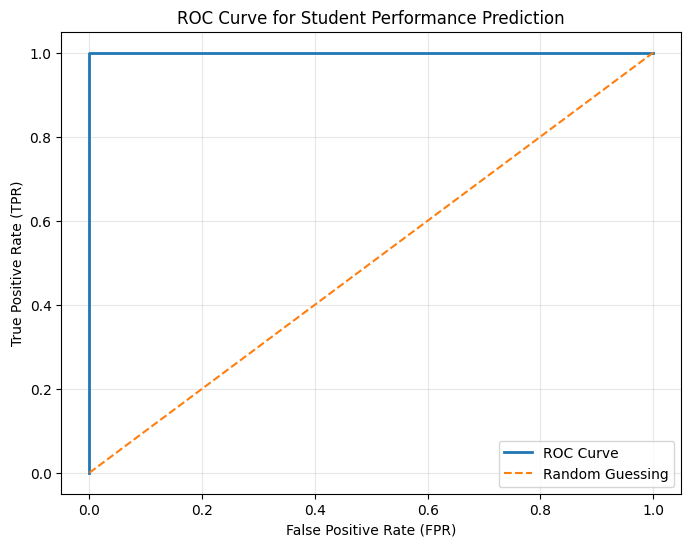

In [7]:
fpr_curve, tpr_curve, thresholds_curve = roc_curve(df['Actual_Binary'], df['Predicted_Pass_Probability'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve, tpr_curve, label='ROC Curve', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Student Performance Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
auc_score = auc(fpr_curve, tpr_curve)
quality = "Poor"

if auc_score >= 0.90:
    quality = "Excellent"
elif auc_score >= 0.80:
    quality = "Good"
elif auc_score >= 0.70:
    quality = "Fair"
elif auc_score >= 0.60:
    quality = "Poor"
else:
    quality = "Random Guessing"

print("AUC Score:", round(auc_score, 3))
print("Model Quality:", quality)

AUC Score: 1.0
Model Quality: Excellent


In [9]:
from sklearn.metrics import accuracy_score

current_accuracy = accuracy_score(df['Actual_Binary'], df['Predicted_Binary'])

summary_table_data = {
    'Metric': ['Accuracy', 'AUC'],
    'What It Evaluates': [
        'Performance at one threshold (default 0.50)',
        'Performance across all possible thresholds'
    ],
    'Current Model Value': [current_accuracy, auc_score]
}

comparison_df = pd.DataFrame(summary_table_data)
print(comparison_df)

     Metric                            What It Evaluates  Current Model Value
0  Accuracy  Performance at one threshold (default 0.50)                  0.9
1       AUC   Performance across all possible thresholds                  1.0




1. **Identification of Passing Students:** The model demonstrates an excellent ability to separate passing and failing students, as indicated by the high AUC score. It can confidently identify students who are on track to succeed.

1.  **False Positives vs. False Negatives:** In an EdTech intervention context, a False Positive (predicting a student will pass when they actually fail) is highly detrimental, as the student misses out on needed help. A False Negative (predicting a student will fail when they would pass) merely results in extra tutoring, which is a lower-risk error.

1.   **Threshold Adjustment:** Because the cost of a student failing unexpectedly is high, the default threshold of 0.50 should be adjusted. We should raise the "Pass" threshold (e.g., to 0.70) so the model only predicts a "Pass" when it is highly certain, ensuring borderline students get flagged for intervention.
2.   **Intervention Program Suitability:** The model is highly suitable for academic intervention programs. By prioritizing a high True Negative Rate (correctly identifying failures), the system can act as an early warning radar for at-risk students.


2.  **Next Steps:** The data science team should recalibrate the operational threshold based on the school's intervention budget (how many students they can afford to tutor) and deploy the model in a shadow-testing phase before making it the primary trigger for academic support.


